In [5]:
import pandas as pd

In [6]:
df = pd.read_csv(r'C:\Users\USER\Desktop\customer-churn-analysis\cleaned_ecommerce_churn_dataset.csv')

In [31]:
import matplotlib.pyplot as plt

In [8]:
import numpy as np

In [10]:
import matplotlib.ticker as mticker

In [11]:
import seaborn as sns

In [12]:
import warnings
warnings.filterwarnings('ignore')

In [13]:
from scipy import stats

In [14]:
df.head()

,order_id,customer_id,age,product_id,country,signup_date,last_purchase_date,cancellations_count,subscription_status,order_date,...,category,gender,order_amount,recency_days,frequency,monetary,tenure_days,avg_order_value,purchase_intensity,inactive_ratio
0,ORD5000,CUST1000,39,PROD200,Canada,2021-01-07,2023-02-21,0,active,2024-08-20,...,Sports,Female,391.05,912,37,391.05,1687,10.568919,0.021932,0.540605
1,ORD5001,CUST1001,61,PROD201,USA,2020-10-19,2021-12-08,0,active,2025-07-17,...,Home,Female,512.16,1352,35,512.16,1767,14.633143,0.019808,0.765139
2,ORD5002,CUST1002,26,PROD202,Pakistan,2023-06-10,2023-09-04,3,cancelled,2025-03-12,...,Clothing,Female,1208.28,717,44,1208.28,803,27.460909,0.054795,0.892902
3,ORD5003,CUST1003,54,PROD203,India,2023-07-30,2024-02-20,4,paused,2024-09-19,...,Beauty,Male,338.64,548,1,338.64,753,338.640000,0.001328,0.727756
4,ORD5004,CUST1004,50,PROD204,India,2020-12-09,2024-09-14,0,active,2024-08-08,...,Electronics,Male,438.62,341,35,438.62,1716,12.532000,0.020396,0.198718


In [15]:
df.describe().round(2)

,age,cancellations_count,unit_price,quantity,order_amount,recency_days,frequency,monetary,tenure_days,avg_order_value,purchase_intensity,inactive_ratio
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,44.08,2.44,324.72,4.95,1025.85,631.22,25.16,1025.85,1286.95,89.45,0.02,0.49
std,14.80,1.70,361.55,2.56,560.79,410.96,14.16,560.79,313.31,178.78,0.01,0.29
min,18.00,0.00,2.85,1.00,22.29,1.00,1.00,22.29,732.00,0.48,0.00,0.00
25%,31.00,1.00,111.13,3.00,551.94,285.00,13.00,551.94,1017.00,21.47,0.01,0.24
50%,45.00,2.00,206.52,5.00,1057.23,586.00,25.00,1057.23,1300.00,40.04,0.02,0.48
75%,57.00,4.00,384.51,7.00,1494.68,907.00,37.00,1494.68,1558.25,81.68,0.03,0.74
max,69.00,5.00,1991.63,9.00,1998.08,1796.00,49.00,1998.08,1827.00,1994.70,0.07,1.00


In [16]:
df.isnull().sum()

order_id               0
customer_id            0
age                    0
product_id             0
country                0
signup_date            0
last_purchase_date     0
cancellations_count    0
subscription_status    0
order_date             0
unit_price             0
quantity               0
preferred_category     0
product_name           0
category               0
gender                 0
order_amount           0
recency_days           0
frequency              0
monetary               0
tenure_days            0
avg_order_value        0
purchase_intensity     0
inactive_ratio         0
dtype: int64

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_id             2000 non-null   str    
 1   customer_id          2000 non-null   str    
 2   age                  2000 non-null   int64  
 3   product_id           2000 non-null   str    
 4   country              2000 non-null   str    
 5   signup_date          2000 non-null   str    
 6   last_purchase_date   2000 non-null   str    
 7   cancellations_count  2000 non-null   int64  
 8   subscription_status  2000 non-null   str    
 9   order_date           2000 non-null   str    
 10  unit_price           2000 non-null   float64
 11  quantity             2000 non-null   int64  
 12  preferred_category   2000 non-null   str    
 13  product_name         2000 non-null   str    
 14  category             2000 non-null   str    
 15  gender               2000 non-null   str    
 16 

In [18]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

3. Target Variable Definition

The dataset has no explicit Churn binary column. We derive it from subscription_status:

subscription_status	Label	Rationale
active	Active (0)	Currently engaged customer
cancelled	Churned (1)	Hard churn — subscription ended
paused	Paused (at-risk)	Soft churn — noted separately, not included in binary target
Decision: Churn = 1 if subscription_status == 'cancelled' (hard churn). It is clearer for modeling. Paused customers are tracked separately as an at-risk group. (soft churn)

In [19]:
df['churn'] = (df['subscription_status'] == 'cancelled').astype('int') 
status__map = {'cancelled':'churn','active':'Active','paused':'Paused'}

df['churn_label'] = df['subscription_status'].map(status__map)


In [20]:
df['churn_label'].value_counts()

churn_label
Active    1204
churn      493
Paused     303
Name: count, dtype: int64

In [21]:
Active_counts = (df['churn_label'] == 'Active').sum()

Active_pct = Active_counts*100/len(df)

print(f'\nActive customer: {Active_pct}%')



Active customer: 60.2%


In [22]:
df['churn_label'] = df['subscription_status'].map(status__map)

In [23]:
df.columns

Index(['order_id', 'customer_id', 'age', 'product_id', 'country',
       'signup_date', 'last_purchase_date', 'cancellations_count',
       'subscription_status', 'order_date', 'unit_price', 'quantity',
       'preferred_category', 'product_name', 'category', 'gender',
       'order_amount', 'recency_days', 'frequency', 'monetary', 'tenure_days',
       'avg_order_value', 'purchase_intensity', 'inactive_ratio', 'churn',
       'churn_label'],
      dtype='str')

In [25]:
counts = df['churn_label'].value_counts()
for status,n in counts.items():
    print(f"{status:<12} {n:>5} ({n/len(df)*100:.1f}%)")

print(f'\nBinary churn rate (cancelled only): {df["churn"].mean()*100:.1f}%')
print(f"  churned : {df['churn'].sum():,}")
print(f'  Active  (0): {(df["churn"]==0).sum():,}  (includes {(df["subscription_status"]=="paused").sum()} paused)')
     

Active        1204 (60.2%)
churn          493 (24.6%)
Paused         303 (15.2%)

Binary churn rate (cancelled only): 24.6%
  churned : 493
  Active  (0): 1,507  (includes 303 paused)


In [26]:
# Create binary target variable
df['target'] = (df['subscription_status'] == 'churn').astype(int)

# Verify
print(df['target'].value_counts())
print(f"\nChurn Rate: {df['target'].mean()*100:.1f}%")

target
0    2000
Name: count, dtype: int64

Churn Rate: 0.0%


In [ ]:
Cell — Churn Distribution

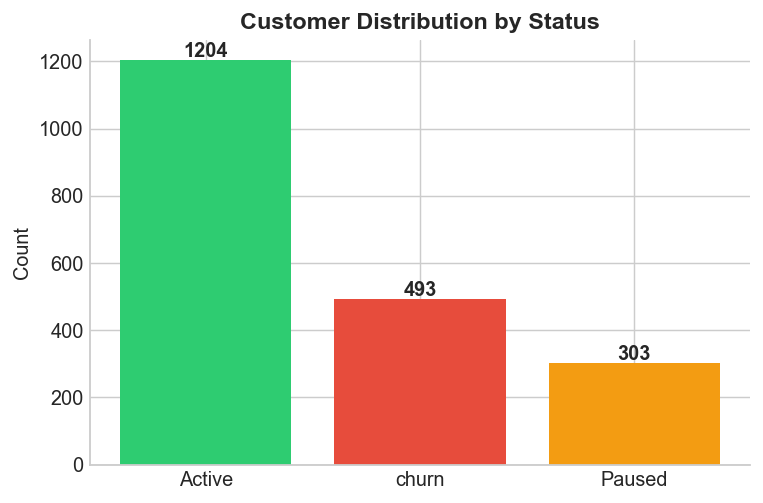

In [33]:
fis, ax = plt.subplots(figsize=(6,4))
counts = df['churn_label'].value_counts()
colors = ['#2ecc71','#e74c3c','#f39c12']
ax.bar(counts.index, counts.values,color=colors)
ax.set_title('Customer Distribution by Status')
ax.set_ylabel('Count')

for i, v in enumerate(counts.values):
    ax.text(i, v+10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/churn_distribution.png', dpi=150)
plt.show()

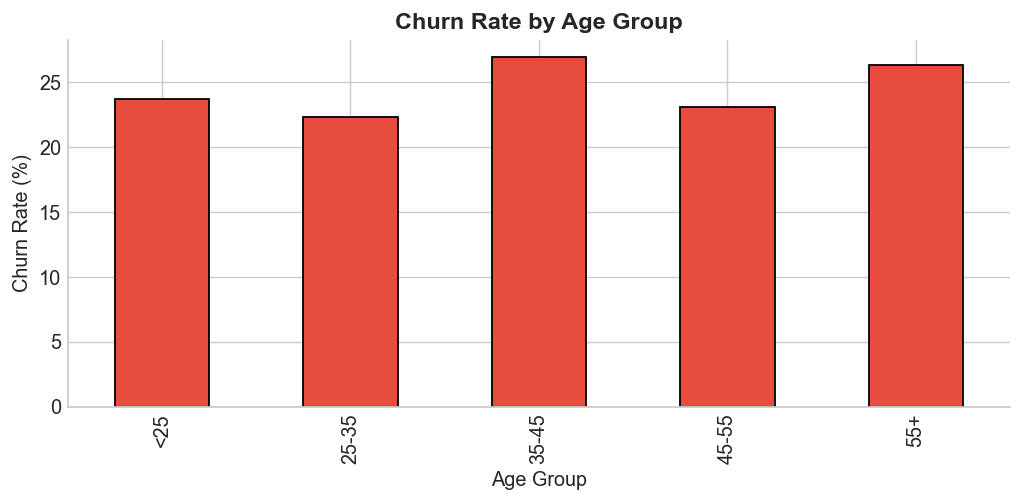

In [34]:
df['age_group'] = pd.cut(df['age'], bins=[0,25,35,45,55,100],
                          labels=['<25','25-35','35-45','45-55','55+'])
churn_age = df.groupby('age_group')['churn'].mean()*100

fig, ax = plt.subplots(figsize=(8,4))
churn_age.plot(kind='bar', ax=ax, color='#e74c3c', edgecolor='black')
ax.set_title('Churn Rate by Age Group')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Age Group')
plt.tight_layout()
plt.savefig('charts/churn_by_age.png', dpi=150)
plt.show()

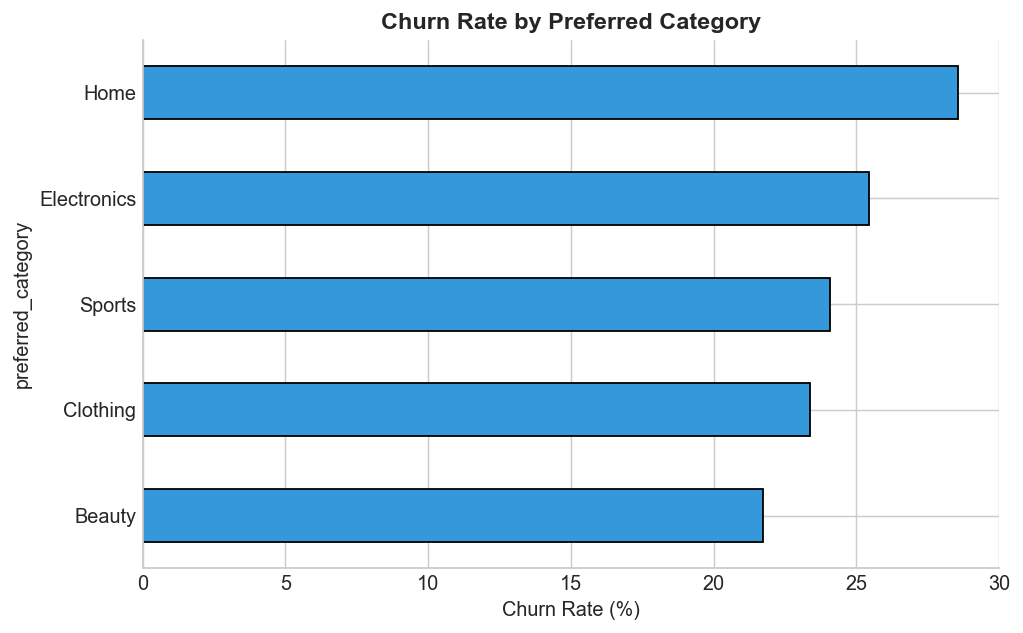

In [35]:
churn_cat = df.groupby('preferred_category')['churn'].mean()*100
churn_cat = churn_cat.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8,5))
churn_cat.plot(kind='barh', ax=ax, color='#3498db', edgecolor='black')
ax.set_title('Churn Rate by Preferred Category')
ax.set_xlabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('charts/churn_by_category.png', dpi=150)
plt.show()